In [2]:
import sys, warnings
sys.unraisablehook = lambda u: None
warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")

In [3]:
import Rbeast as rb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def read_series(path, date_col=0, usecols=None, drop_first_col=False, sort=False):
    df = pd.read_csv(path, parse_dates=[date_col], index_col=date_col, usecols=usecols)
    if drop_first_col:
        df = df.drop(columns=df.columns[0])
    s = df.squeeze()
    s = s.loc['2005':]
    return s.sort_index() if sort else s


DATA = Path("/home/py/groundwater/data")
BOW_VALLEY = DATA / "bow_valley"
STREAM = BOW_VALLEY / "stream"

df = pd.read_csv(DATA / "gown" / "combined_absval_20052024_filled.csv", parse_dates=[0], index_col=0)
GOWN_raw = pd.read_csv(DATA / "gown" / "combined_absval.csv", parse_dates=[0], index_col=0)
GOWN_mbtoc = pd.read_csv(DATA / "gown" / "combined_mbtoc.csv", parse_dates=[0], index_col=0)

marmot_creek_wells = ['0931', '0301', '0303', '0386', '0305']
canmore_wells = ['0764', '0760', '0759', '0364']

krns = read_series(STREAM / "krns_daily.csv")
bl   = read_series(STREAM / "05BF025_BarrierLk_TAU_Day_Mean.csv")
lkl  = read_series(STREAM / "05BF009.csv")
jcnc = read_series(STREAM / "05BH013.csv", sort=True)
brac_e = read_series(STREAM / "cr.csv", usecols=[0, 2])
brab   = read_series(STREAM / "brab_elevation.csv", usecols=[0, 2])
brac = read_series(STREAM / "cr_flow.csv", date_col=1, drop_first_col=True)

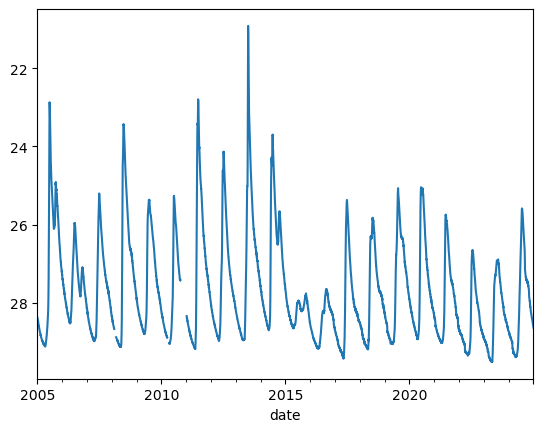

In [4]:
GOWN_mbtoc['0764'].plot().invert_yaxis()

In [5]:
df_m = df.resample("MS").mean()
df_m.index = df_m.index + pd.Timedelta(days=14)
df_m.columns = df_m.columns.astype(int)

In [6]:
ws = [931, 301, 303, 386, 305, 764, 760, 759, 364]

In [7]:
def plot_beast(y, label, n_tcp=1, ylab='WL (m)'):
    o = rb.beast(
        y,
        start=[2005, 1, 1],
        deltat="1 month",
        period="1 year",                  # seasonal cycle length
        season="harmonic",                # harmonic seasonal model
        tcp_minmax=[0,n_tcp],
        scp_minmax=[0,10],
        print_progress=False, print_options=False, quiet=True,
        ci=True,
        tseg_leftmargin=24,
        tseg_rightmargin=24
    )

    t, s, tr = o.time, o.season, o.trend

    fig, ax = plt.subplots(3, 1, figsize=(8, 5), sharex=True, dpi=200)

    # observed + fit
    ax[0].plot(t, y, c="k", lw=1, label="observed")
    ax[0].plot(t, tr.Y + s.Y, c="0.6", lw=0.8, label="fit")
    ax[0].legend(fontsize=8); ax[0].set_ylabel(f"{ylab}")

    # season
    ax[1].fill_between(t, s.CI[:,0], s.CI[:,1], color="tab:green", alpha=.25, lw=0)
    ax[1].plot(t, s.Y, c="tab:green", lw=1)
    ax[1].set_ylabel("season")

    # trend
    ax[2].fill_between(t, tr.CI[:,0], tr.CI[:,1], color="tab:blue", alpha=.25, lw=0)
    ax[2].plot(t, tr.Y, c="tab:blue", lw=1)
    ax[2].set_ylabel(f"trend {ylab}")

    # changepoints
    for cps, cpr, col, row in [(s.cp, s.cpPr, "tab:green", 1),
                                (tr.cp, tr.cpPr, "tab:blue", 2)]:
        keep = cps[~np.isnan(cps)]
        for cp in keep:
            ax[row].axvline(cp, c=col, ls="--", lw=.9)

    ax[-1].set_xlabel("year")
    fig.suptitle(f"{label}")
    fig.tight_layout()

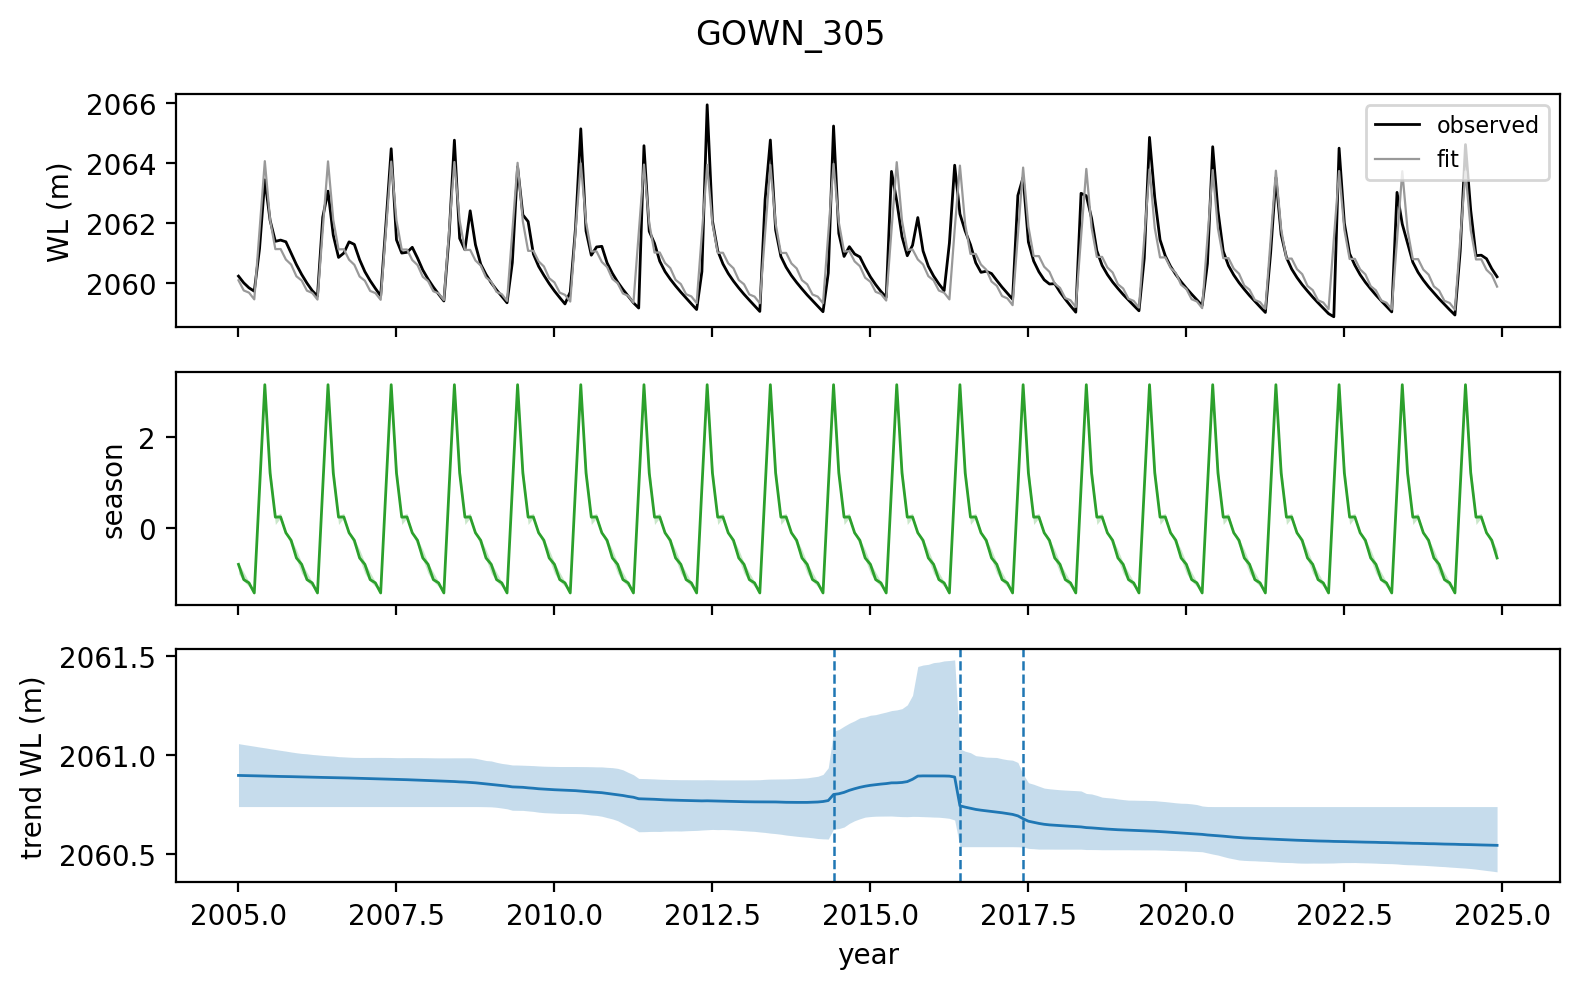

In [8]:
plot_beast(df_m[305], 'GOWN_305', n_tcp=3)

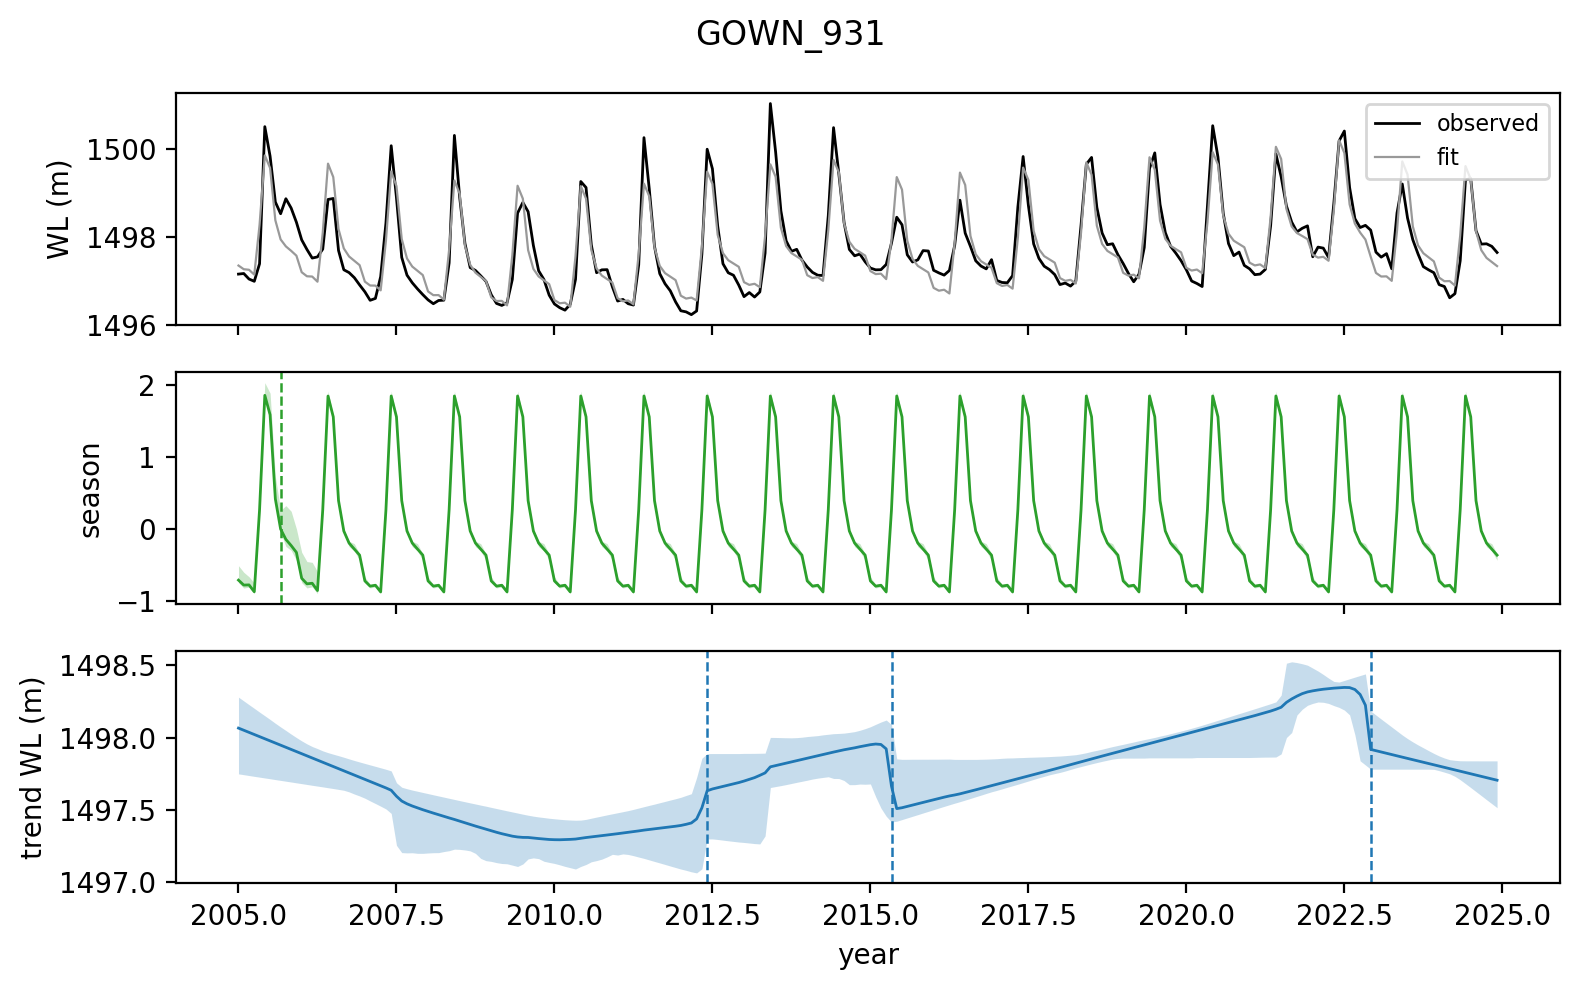

In [9]:
plot_beast(df_m[931], 'GOWN_931', n_tcp=3)

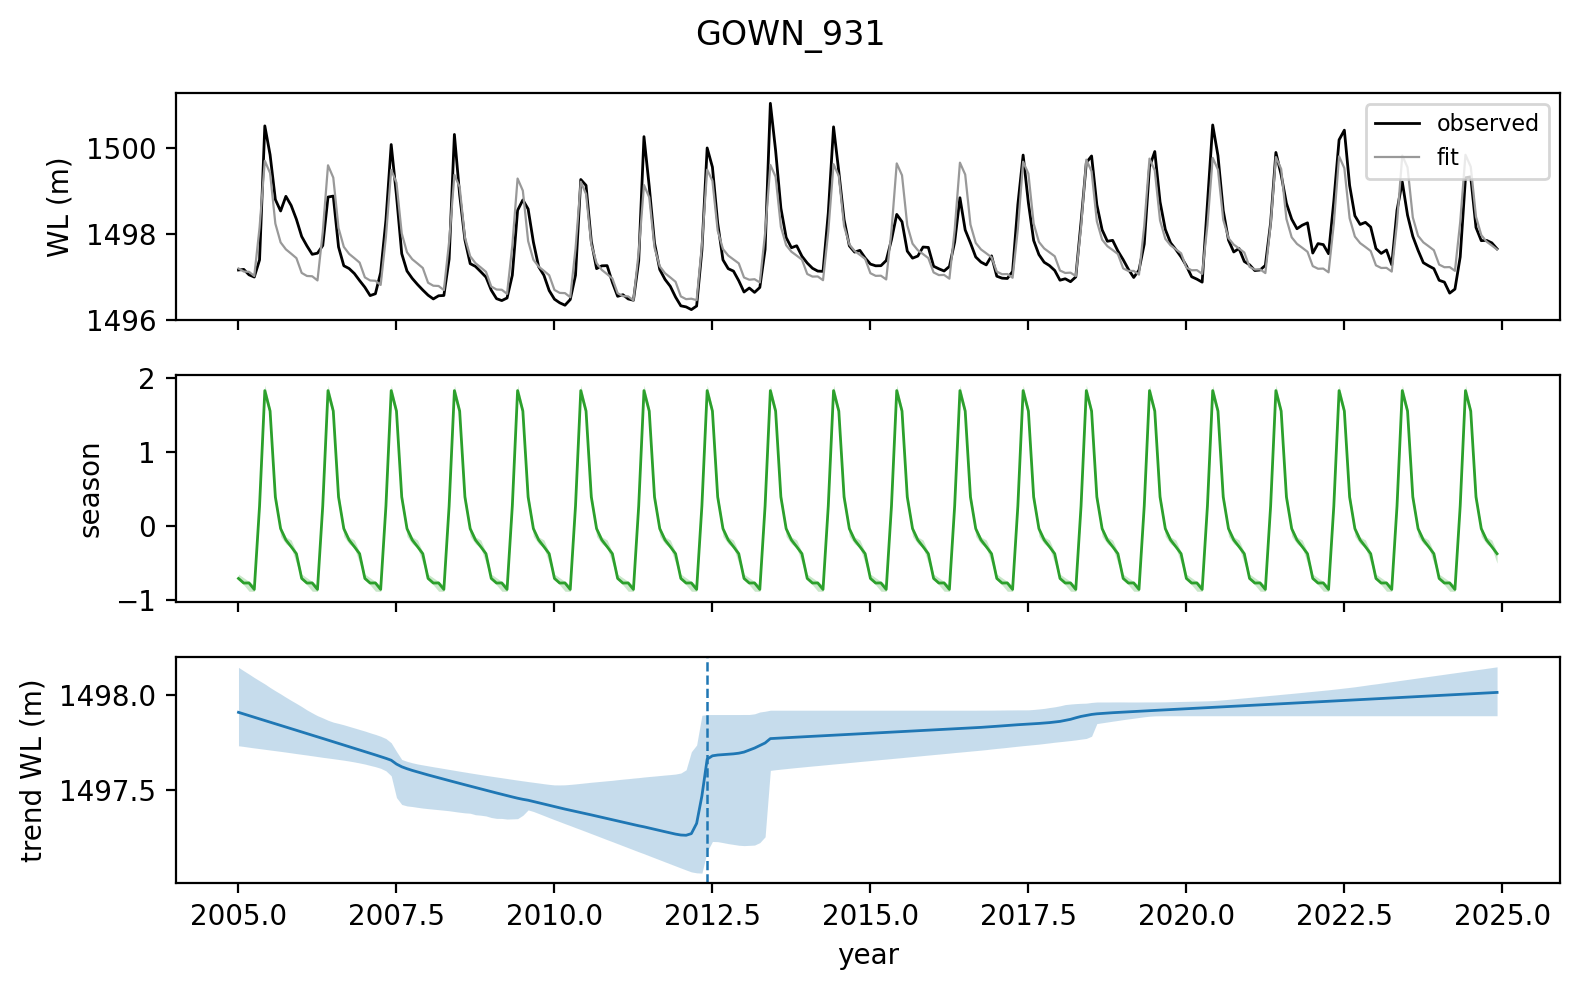

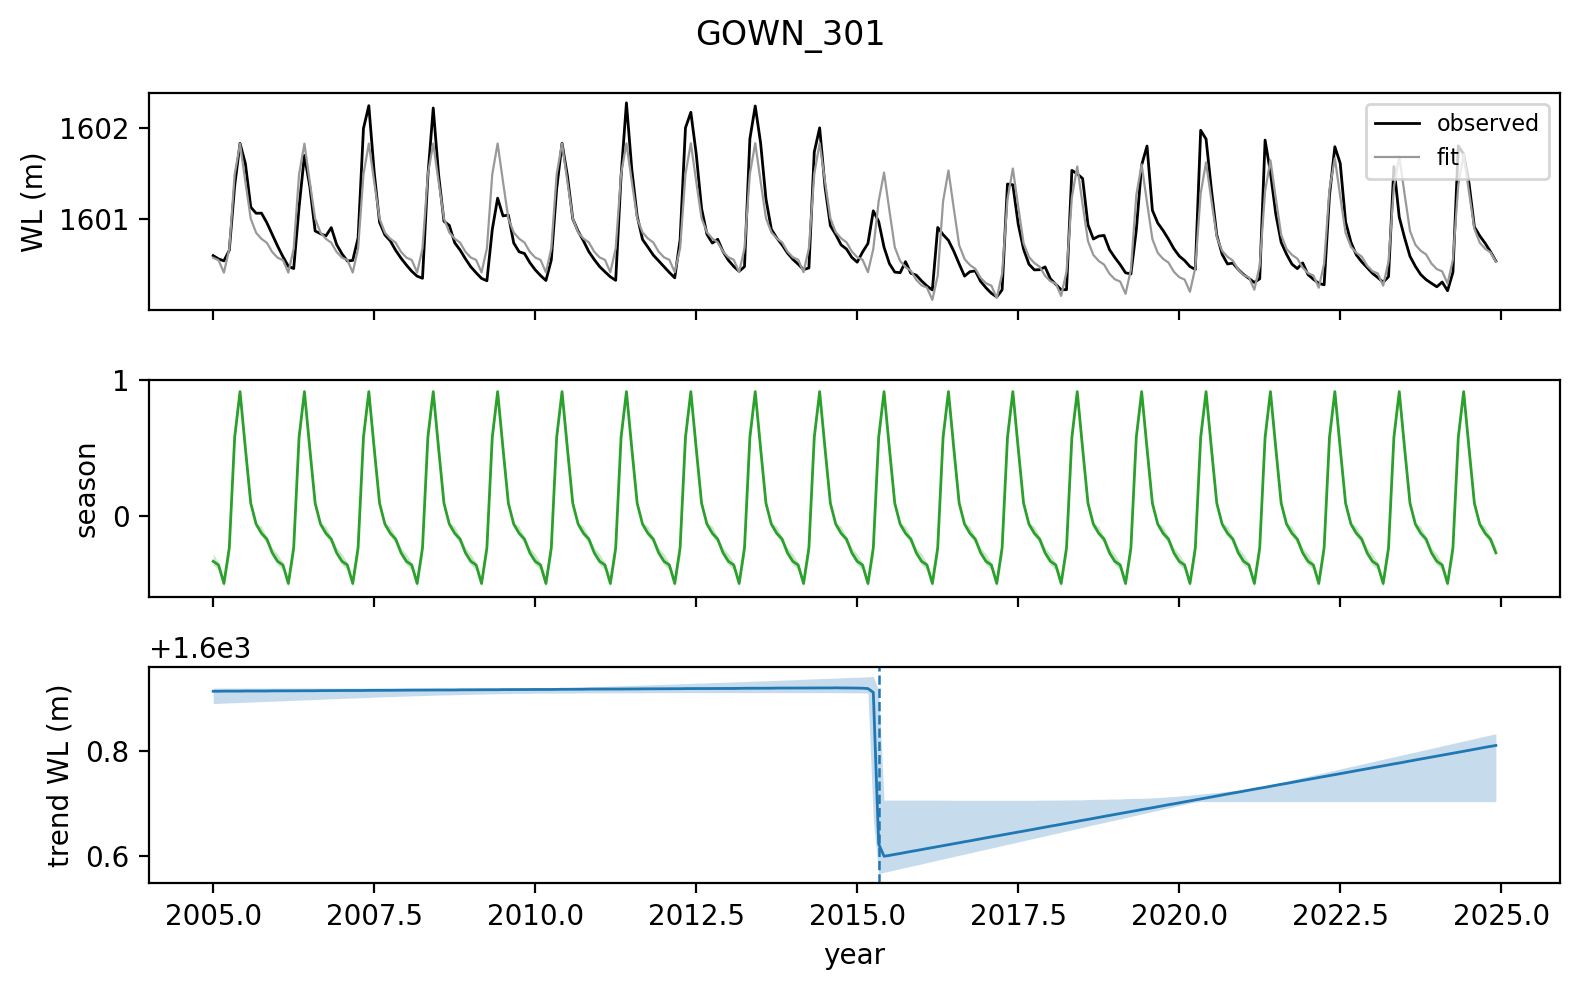

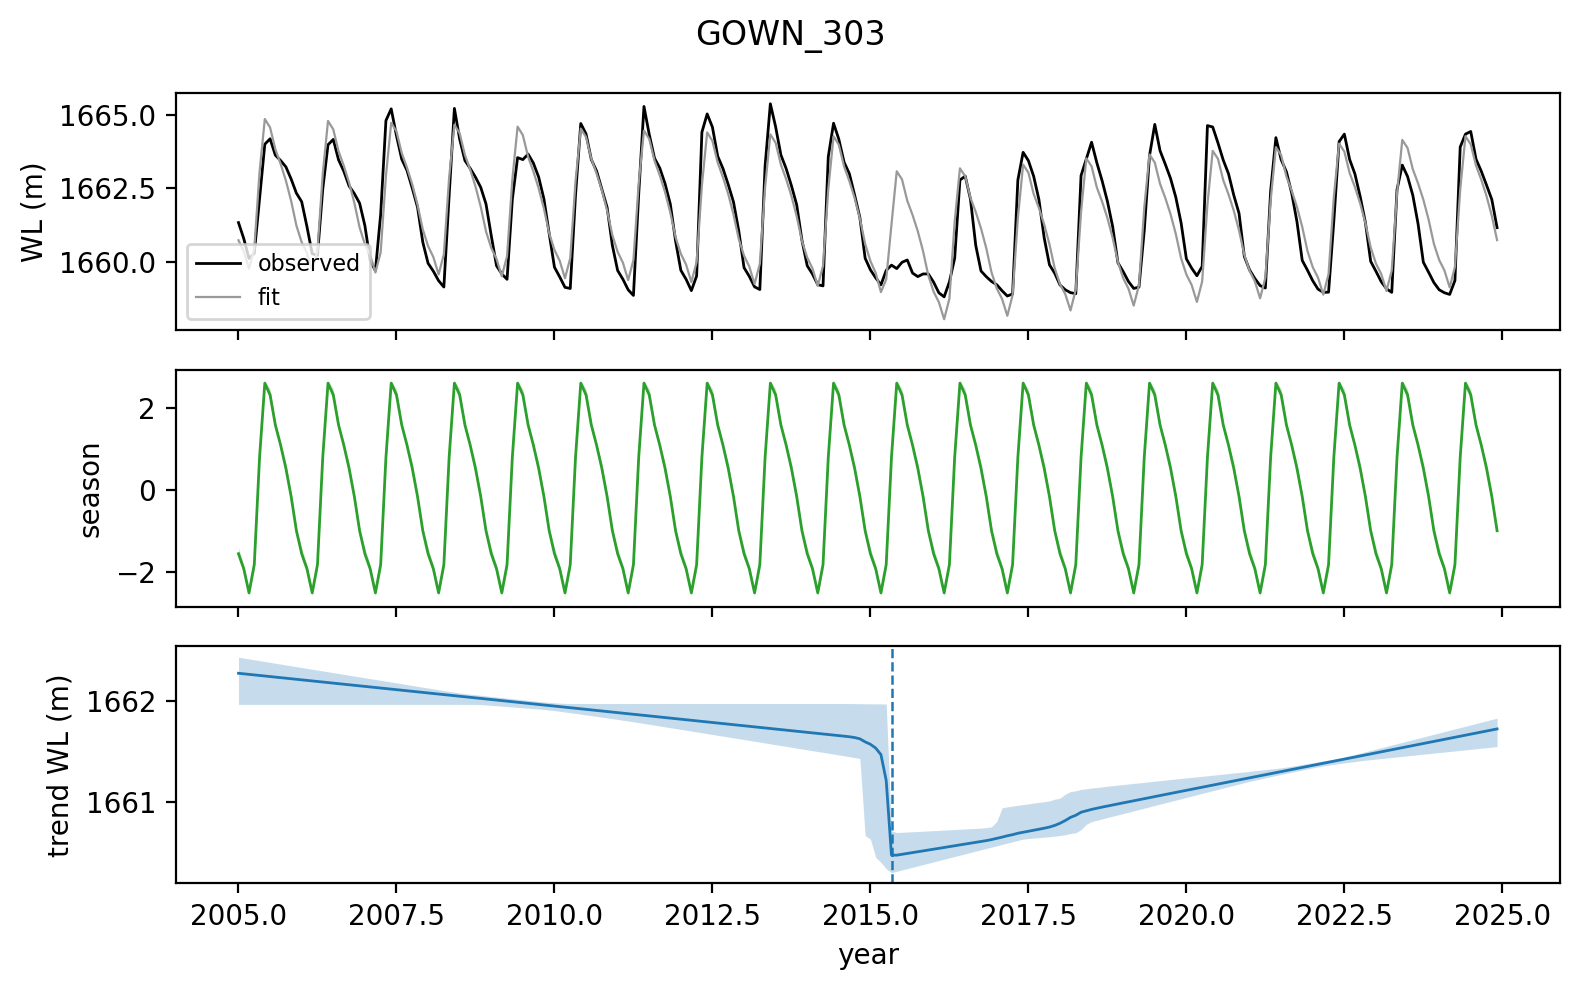

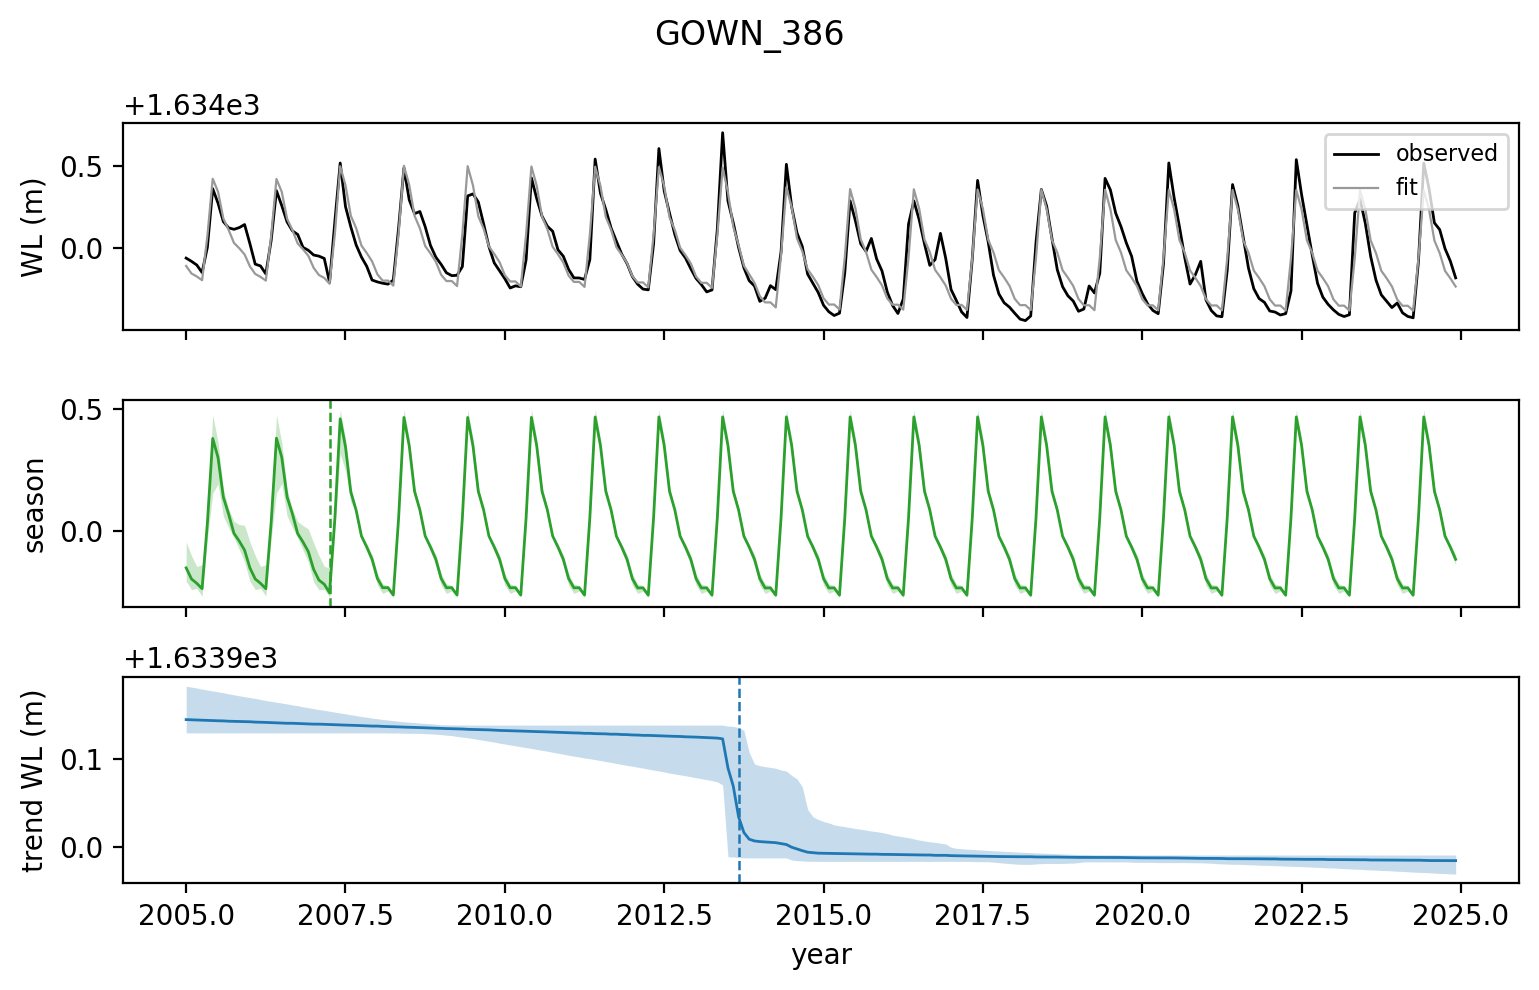

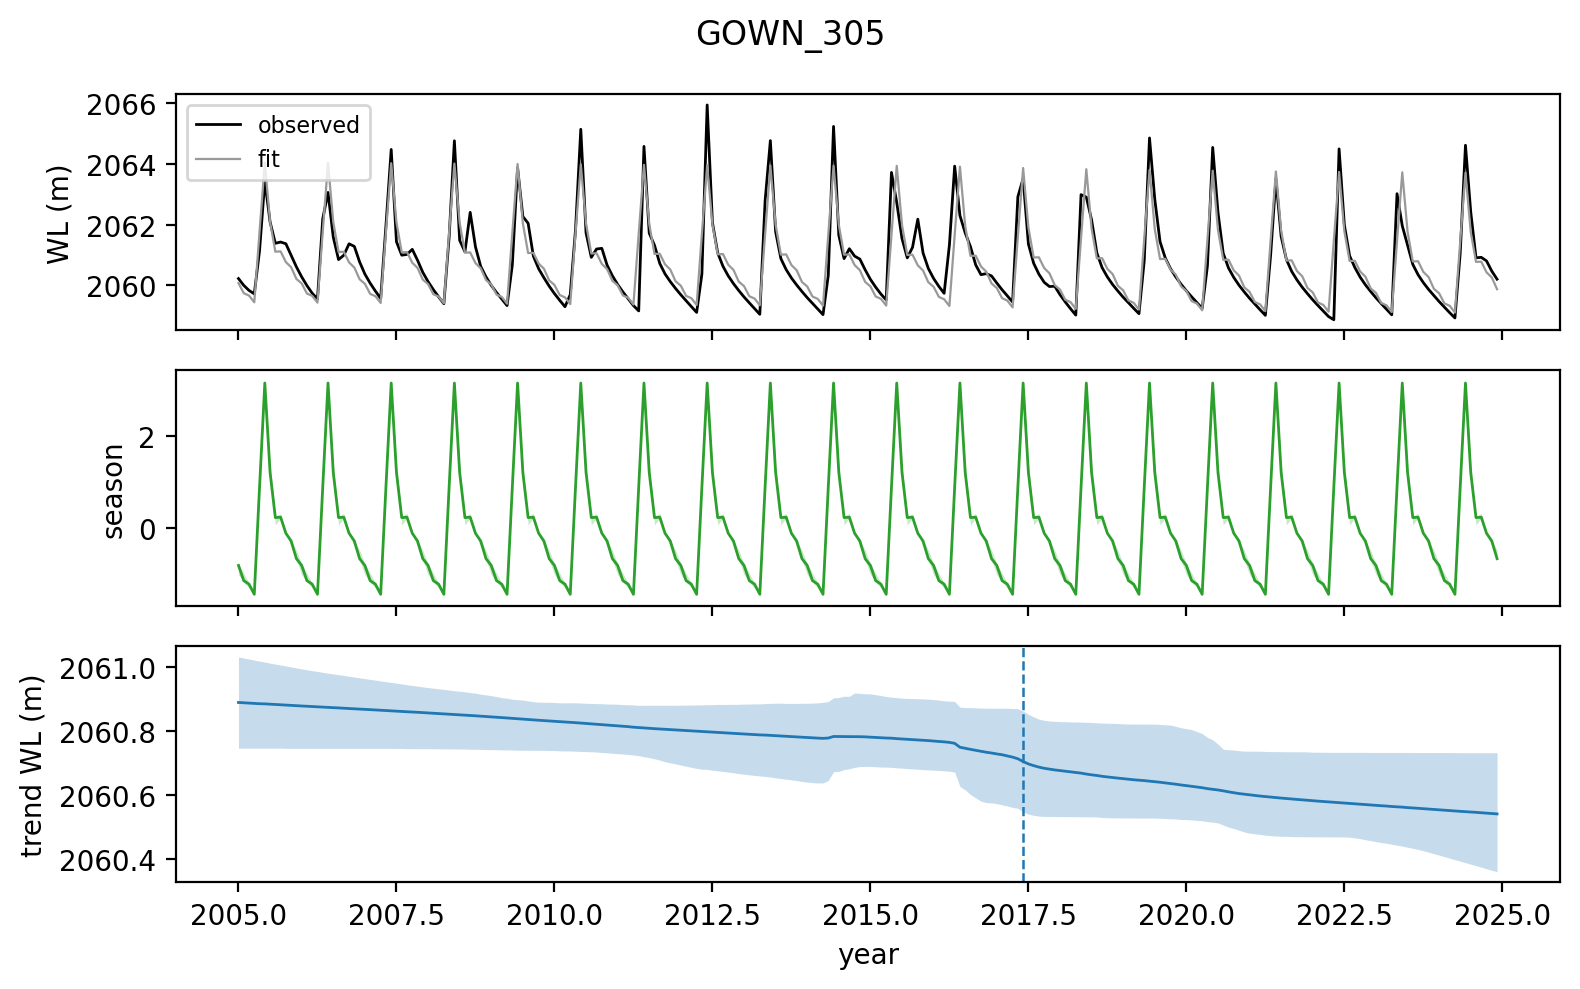

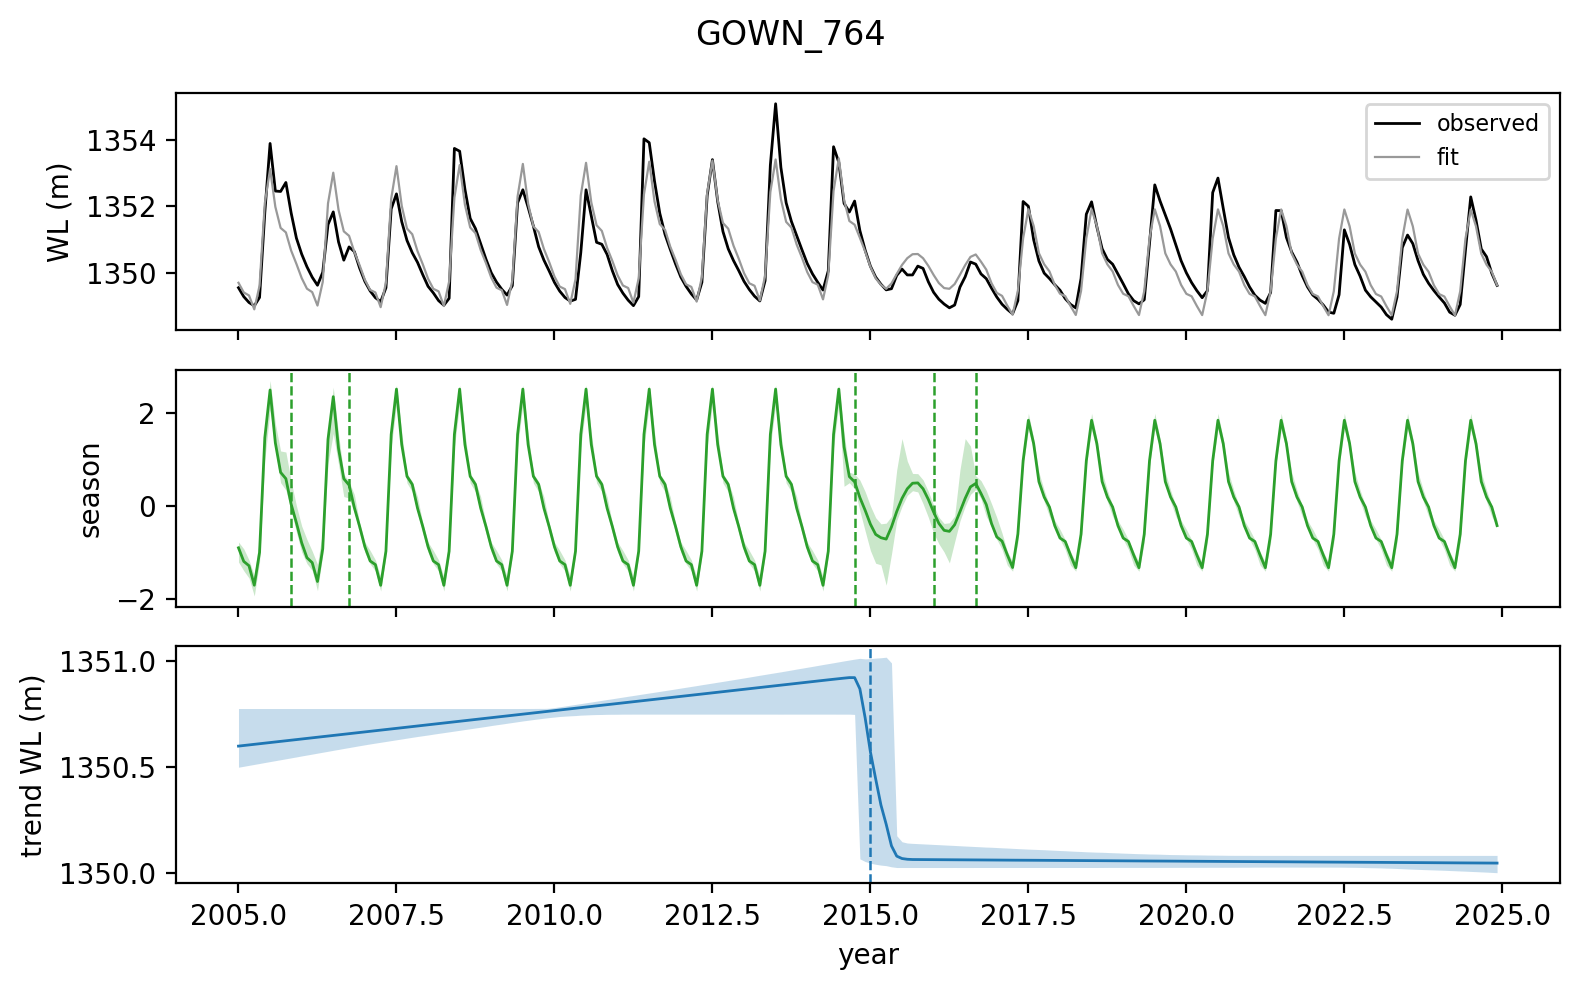

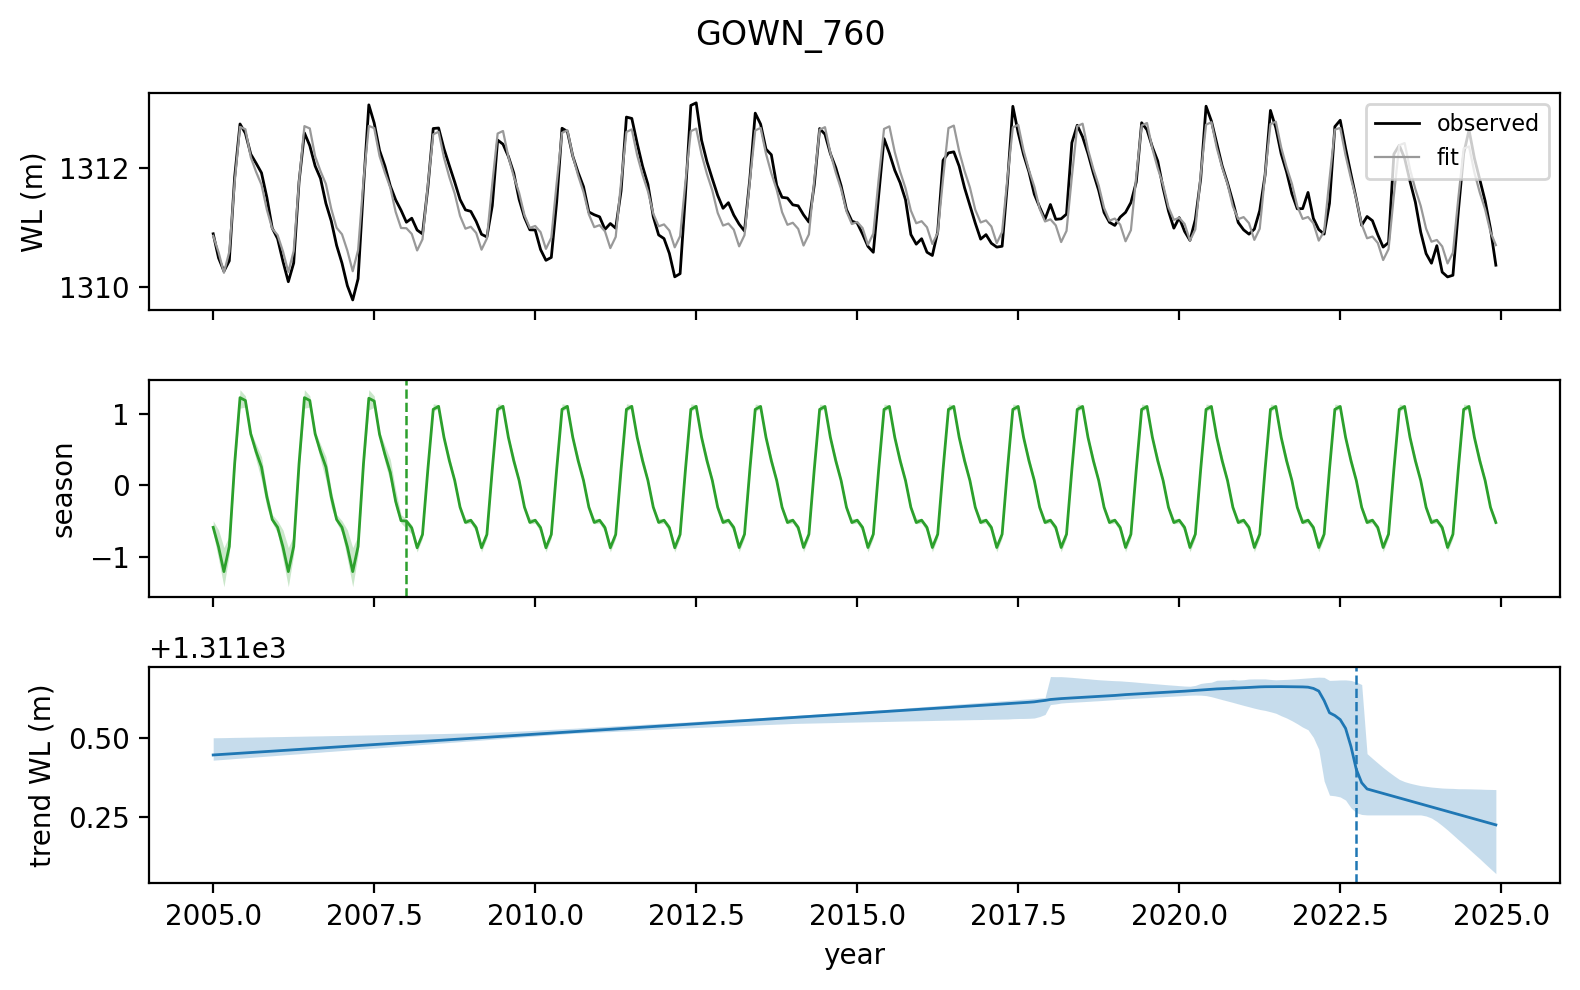

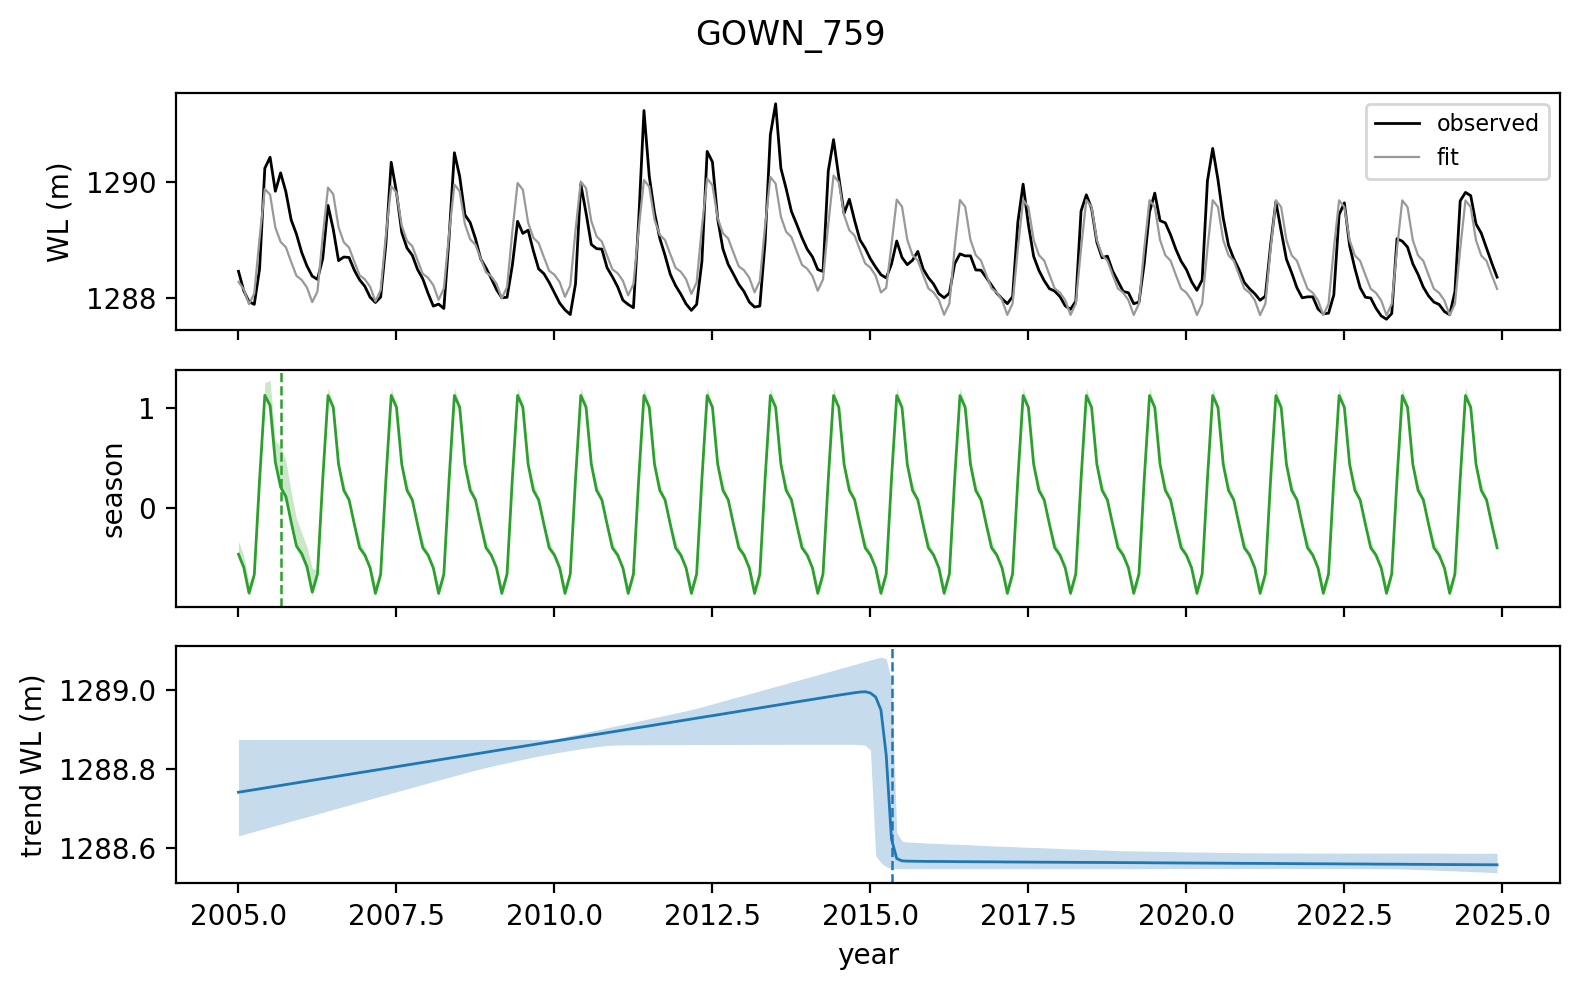

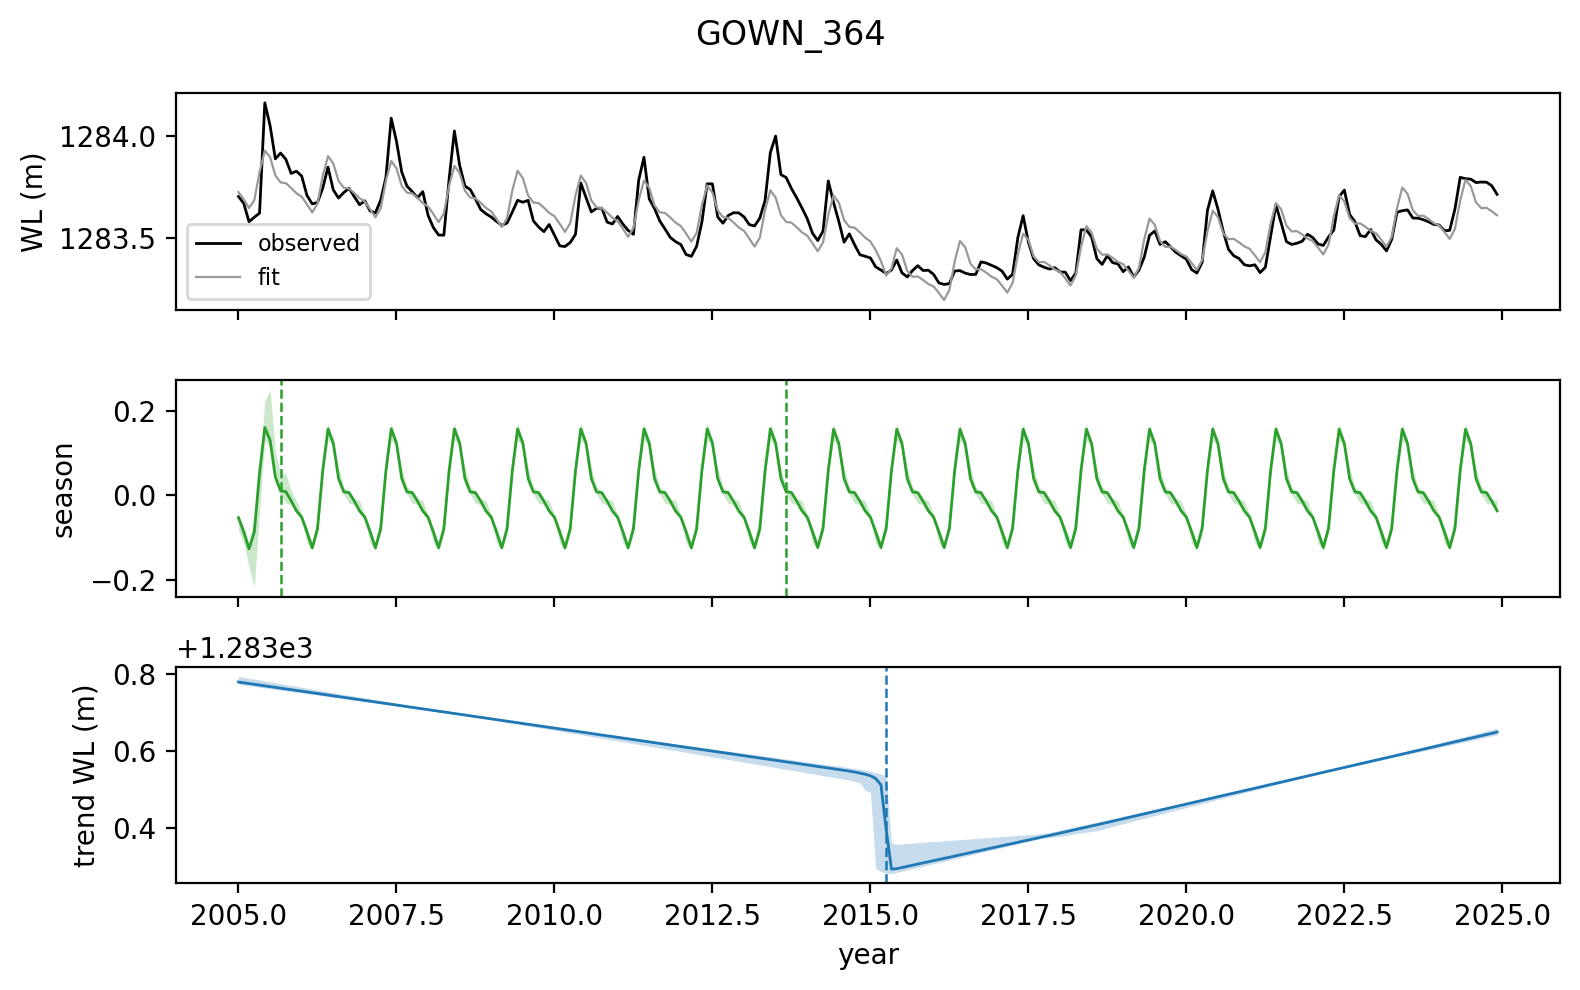

In [10]:
for w in ws:
    y = df_m[w].values
    plot_beast(y, f'GOWN_{w}')

In [11]:
brac_e = brac_e.resample('MS').mean()
krns = krns.resample('MS').mean()

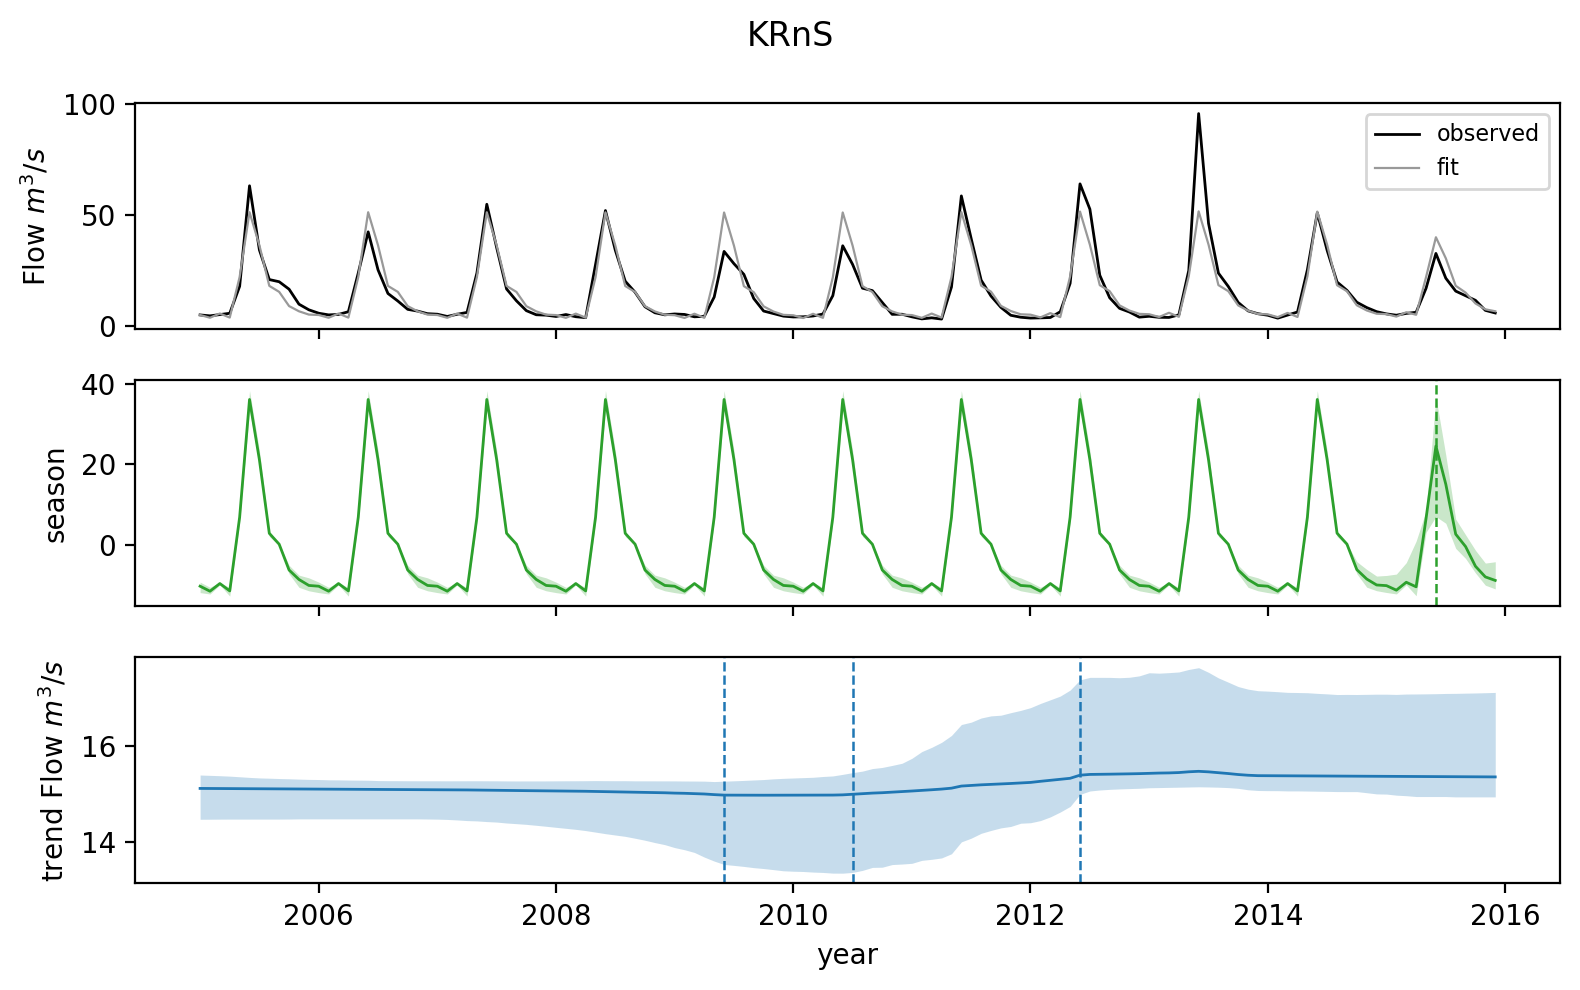

In [12]:
plot_beast(krns, 'KRnS', ylab='Flow $m^3/s$', n_tcp=3)

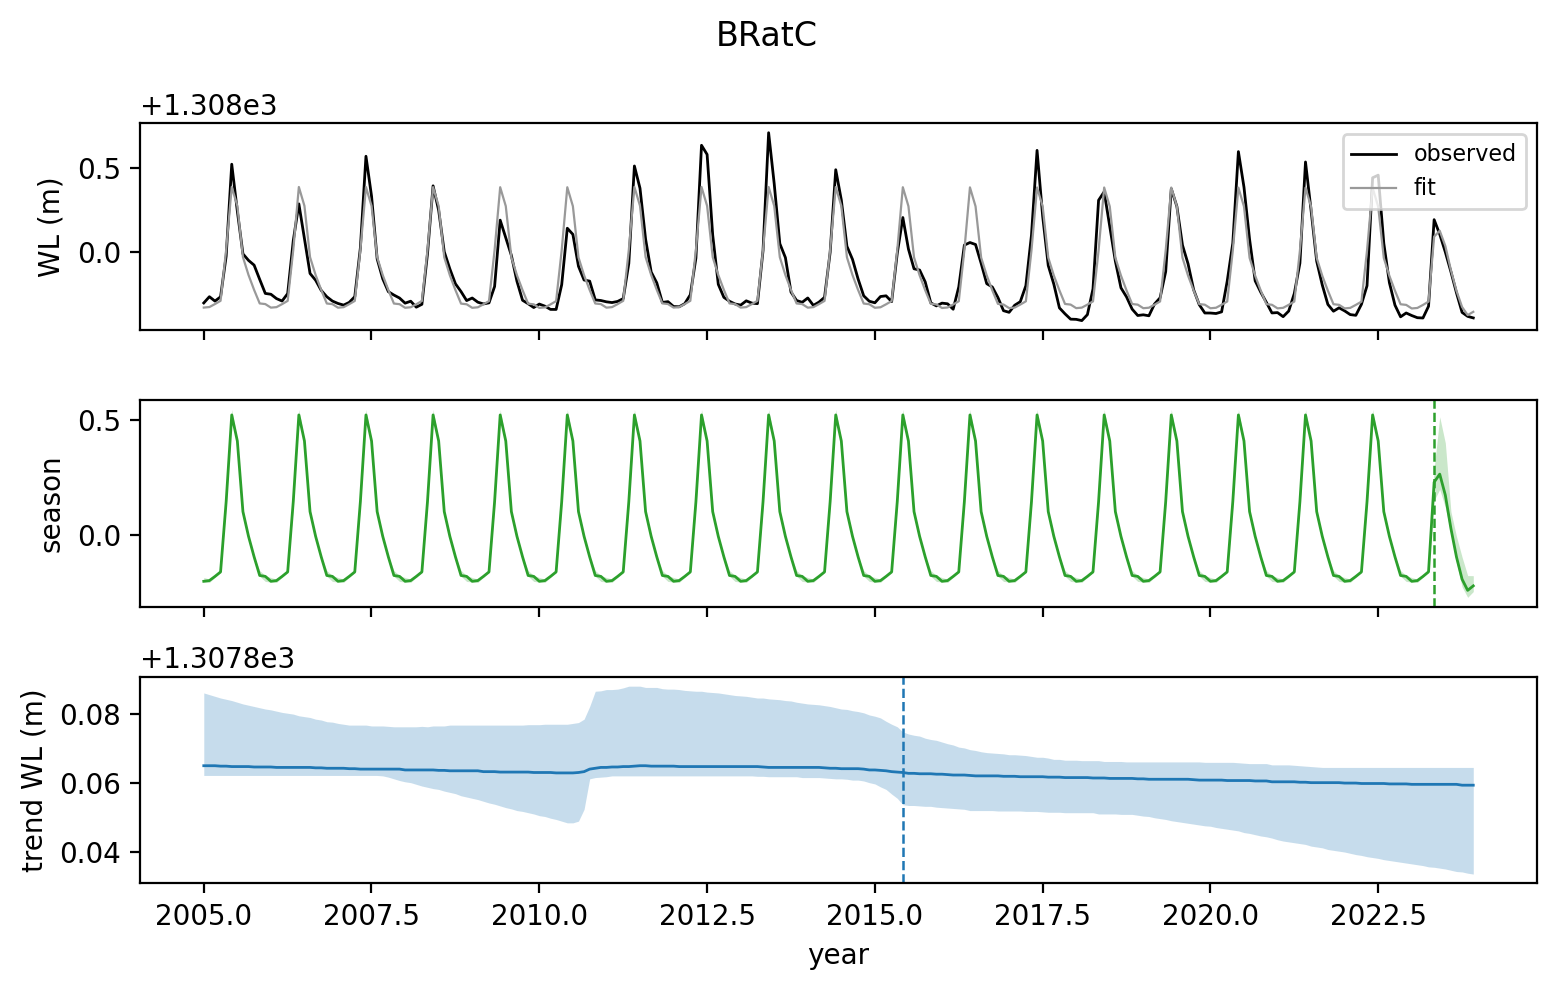

In [13]:
plot_beast(brac_e, 'BRatC')

<Axes: xlabel='Date'>

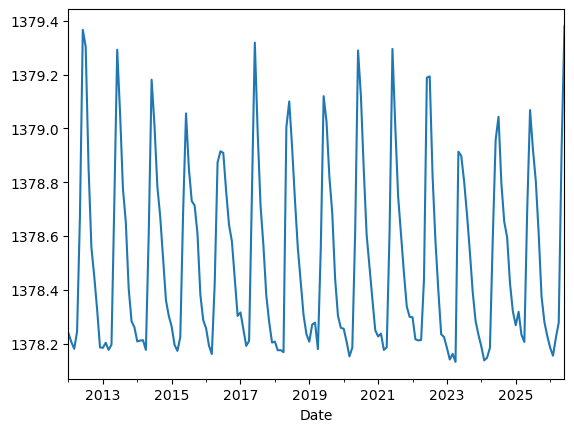

In [16]:
brab.resample('MS').mean().plot()

<Axes: xlabel='Date'>

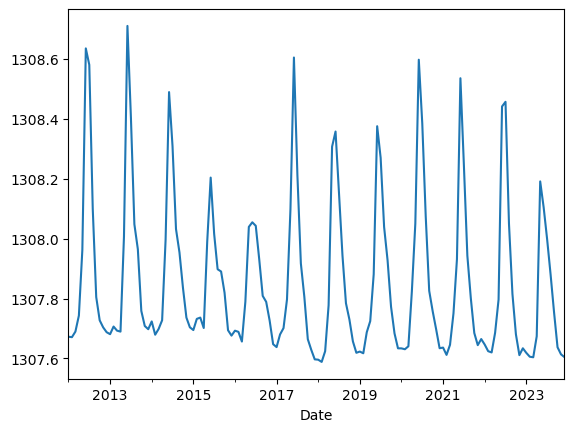

In [19]:
brac_e.loc['2012':].plot()